# 3 · Exploratory data analysis

One row per product. Each section: finding → what it changed downstream.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BLUE, INK, MUTED = '#2a78d6', '#0b0b0b', '#52514e'
plt.rcParams.update({
    'figure.figsize': (8, 4.5), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': MUTED, 'axes.labelcolor': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': '#e6e5e1', 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.titlelocation': 'left', 'axes.titleweight': 'bold',
})

p = pd.read_csv('../data/amazon_products_deduped.csv')
brands = p.groupby('brand').size().sort_values(ascending=False)
print(f'{len(p)} products, {len(brands)} brands')

7946 products, 493 brands


## Brands: 28% have one product → partial pooling by brand

In [2]:
print(brands.describe().round(1))
for k in [1, 2, 5, 10, 50]:
    print(f'brands with <= {k:>2} products: {(brands <= k).mean():.0%}')
brands.head(15)

count    493.0
mean      16.1
std       38.5
min        1.0
25%        1.0
50%        4.0
75%       15.0
max      508.0
dtype: float64
brands with <=  1 products: 28%
brands with <=  2 products: 41%
brands with <=  5 products: 56%
brands with <= 10 products: 69%
brands with <= 50 products: 93%


brand
Hp               508
Apple            251
Canon            242
Samsung          224
Lenovo           172
Asus             166
Epson            166
Amazon Basics    163
Brother          154
Logitech         151
Dell             151
Sony             150
Ugreen           145
Garmin           117
Energizer        109
dtype: int64

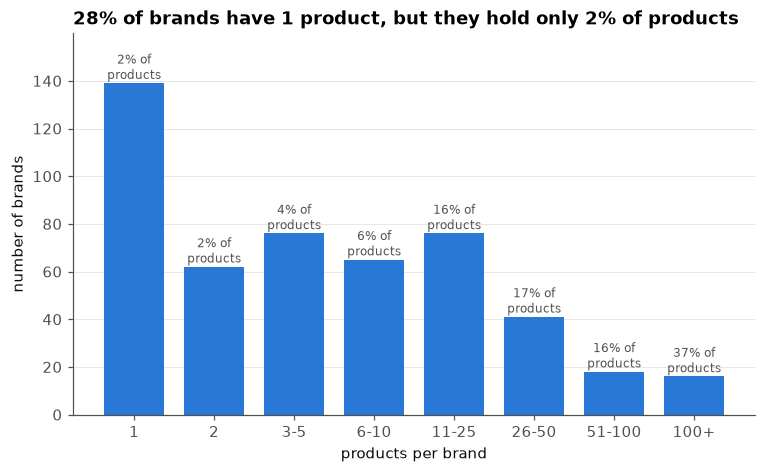

In [3]:
buckets = pd.cut(brands, [0, 1, 2, 5, 10, 25, 50, 100, np.inf],
                 labels=['1', '2', '3-5', '6-10', '11-25', '26-50', '51-100', '100+'])
counts = buckets.value_counts().sort_index()
prods = brands.groupby(buckets, observed=False).sum()
fig, ax = plt.subplots()
ax.bar(counts.index.astype(str), counts.values, color=BLUE, width=0.75)
for i, (nb_, np_) in enumerate(zip(counts, prods)):
    ax.text(i, nb_, f'{np_ / prods.sum():.0%} of\nproducts', ha='center', va='bottom', color=MUTED, fontsize=8)
ax.set_ylim(0, counts.max() * 1.15)
ax.set_xlabel('products per brand')
ax.set_ylabel('number of brands')
ax.set_title(f'{(brands == 1).mean():.0%} of brands have 1 product, but they hold only {prods.iloc[0] / prods.sum():.0%} of products')
ax.grid(axis='x', visible=False);

## Price varies ~15x across categories → compare prices within category

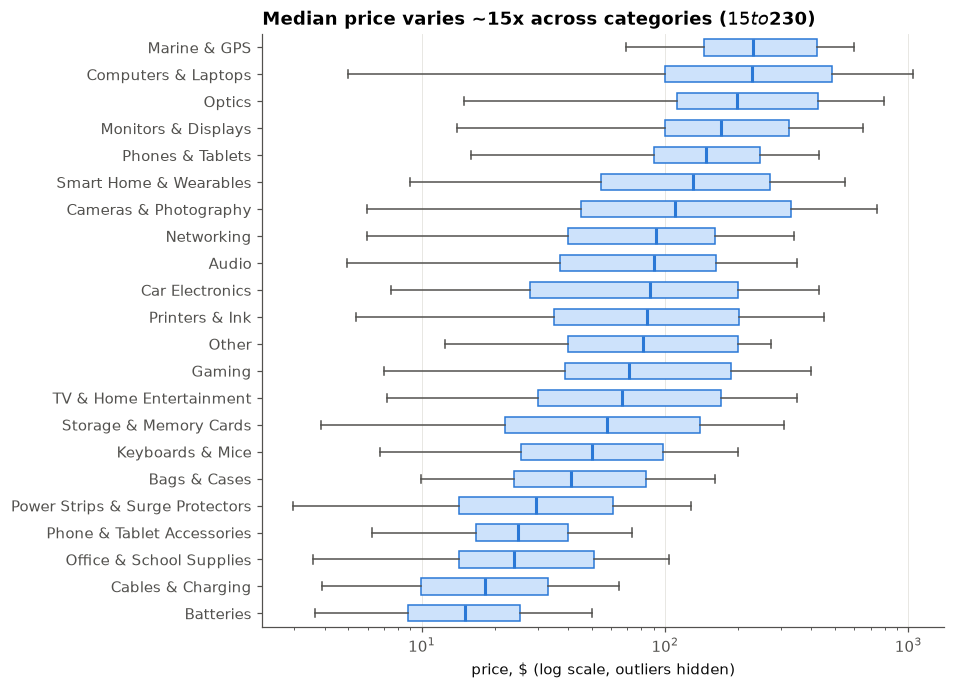

In [4]:
order = p.groupby('category')['current_price'].median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 7))
ax.boxplot([p.loc[p.category == c, 'current_price'].dropna() for c in order], orientation="horizontal",
           tick_labels=order, showfliers=False, widths=0.6, patch_artist=True,
           boxprops=dict(facecolor='#cde2fb', edgecolor=BLUE), medianprops=dict(color=BLUE, lw=2),
           whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
ax.set_xscale('log')
ax.set_xlabel('price, $ (log scale, outliers hidden)')
med = p.groupby('category')['current_price'].median()
ax.set_title(f'Median price varies ~{med.max() / med.min():.0f}x across categories (${med.min():.0f} to ${med.max():.0f})')
ax.grid(axis='y', visible=False);

## Cheap items have more reviews → reviews measure volume, not prestige

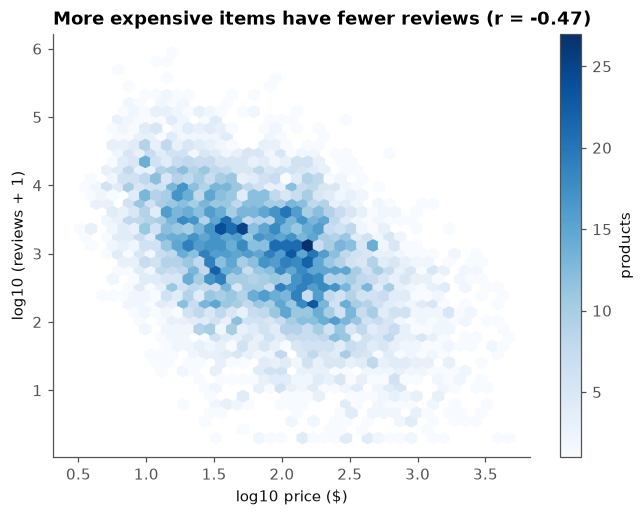

In [5]:
q = p.dropna(subset=['current_price', 'number_of_reviews'])
q = q[q.current_price > 0]
fig, ax = plt.subplots(figsize=(7, 5))
hb = ax.hexbin(np.log10(q.current_price), np.log10(q.number_of_reviews + 1), gridsize=40, cmap='Blues', mincnt=1)
fig.colorbar(hb, ax=ax, label='products')
ax.set_xlabel('log10 price ($)')
ax.set_ylabel('log10 (reviews + 1)')
r = np.corrcoef(np.log(q.current_price), np.log1p(q.number_of_reviews))[0, 1]
ax.set_title(f'More expensive items have fewer reviews (r = {r:.2f})')
ax.grid(False);

## Sales are binned lower bounds → treat as intervals

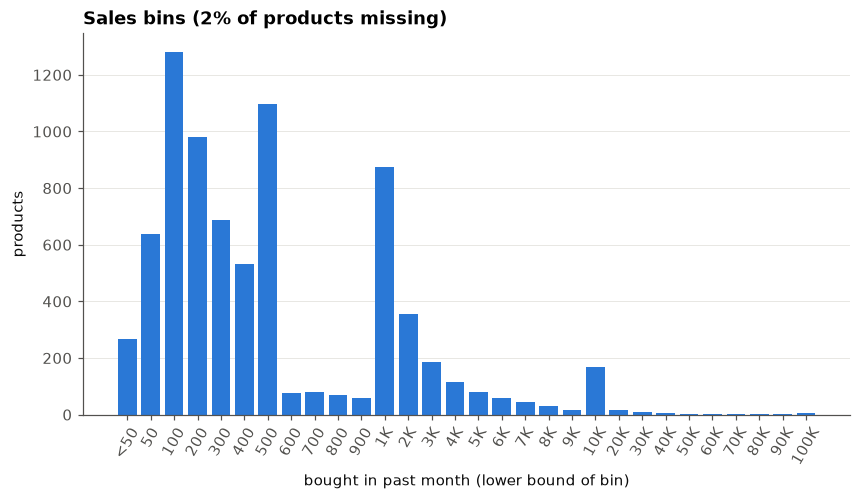

In [6]:
b = p['bought_in_last_month'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(range(len(b)), b.values, color=BLUE, width=0.8)
ax.set_xticks(range(len(b)), ['<50' if v == 0 else f'{int(v):,}' if v < 1000 else f'{int(v/1000)}K' for v in b.index], rotation=60)
ax.set_xlabel('bought in past month (lower bound of bin)')
ax.set_ylabel('products')
ax.set_title(f'Sales bins ({p.bought_in_last_month.isna().mean():.0%} of products missing)')
ax.grid(axis='x', visible=False);

## Small brands' badge rates scatter by chance → partial pooling

Dashed lines: range expected from chance alone.

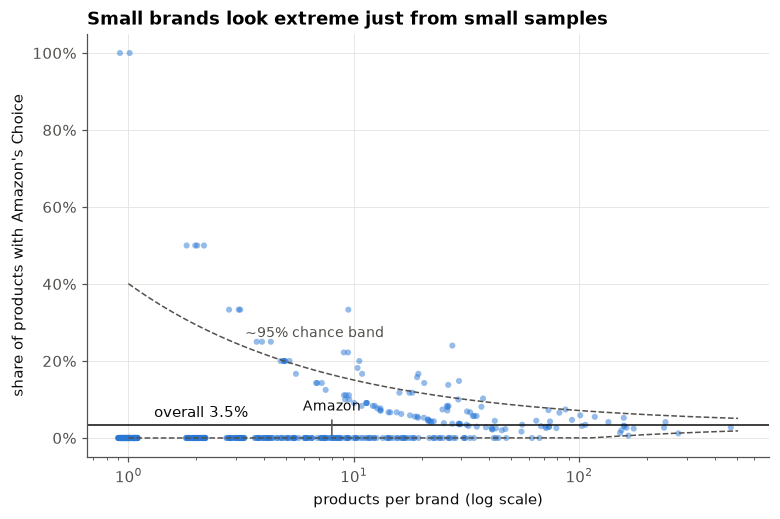

In [7]:
t = p.assign(ac=p['badge_hits'] > 0)  # badged on any scrape
g = t.groupby('brand')['ac'].agg(['mean', 'size'])
base = t['ac'].mean()
n = np.logspace(0, np.log10(g['size'].max()), 200)
se = np.sqrt(base * (1 - base) / n)

fig, ax = plt.subplots(figsize=(8, 5))
jitter = np.random.default_rng(0).uniform(0.9, 1.1, len(g))
ax.scatter(g['size'] * jitter, g['mean'], s=16, color=BLUE, alpha=0.5, edgecolor='none')
ax.plot(n, base + 2 * se, '--', color=MUTED, lw=1)
ax.plot(n, np.clip(base - 2 * se, 0, None), '--', color=MUTED, lw=1)
ax.axhline(base, color=INK, lw=1)
ax.set_xscale('log')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.set_xlabel('products per brand (log scale)')
ax.set_ylabel("share of products with Amazon's Choice")
ax.set_title("Small brands look extreme just from small samples")
ax.annotate(f'overall {base:.1%}', (1.3, base), xytext=(0, 5), textcoords='offset points', color=INK)
ax.annotate('~95% chance band', (3, base + 2 * np.sqrt(base * (1 - base) / 3)), xytext=(6, 4), textcoords='offset points', color=MUTED, fontsize=9)
ax.annotate('Amazon', (g.loc['Amazon', 'size'], g.loc['Amazon', 'mean']), xytext=(0, 18), textcoords='offset points',
            color=INK, fontsize=9, ha='center', arrowprops=dict(arrowstyle='-', color=MUTED));

## Reviews and price vs sales

Rank correlations (sales are binned); "within category" ranks inside each category first.

In [8]:
x = p.dropna(subset=['bought_in_last_month', 'number_of_reviews'])
pairs = [('number_of_reviews', 'reviews'), ('current_price', 'price'), ('rating', 'rating')]
rows = []
for col, name in pairs:
    y = x.dropna(subset=[col])
    ranks = y.groupby('category')[[col, 'bought_in_last_month']].rank(pct=True)
    rows.append({'vs bought_in_last_month': name, 'n': len(y),
                 'Spearman': y[col].corr(y['bought_in_last_month'], method='spearman'),
                 'Spearman within category': ranks[col].corr(ranks['bought_in_last_month'])})
pd.DataFrame(rows).set_index('vs bought_in_last_month').round(2)

,n,Spearman,Spearman within category
vs bought_in_last_month,,,
reviews,7717,0.62,0.58
price,5746,-0.56,-0.47
rating,7717,0.22,0.16


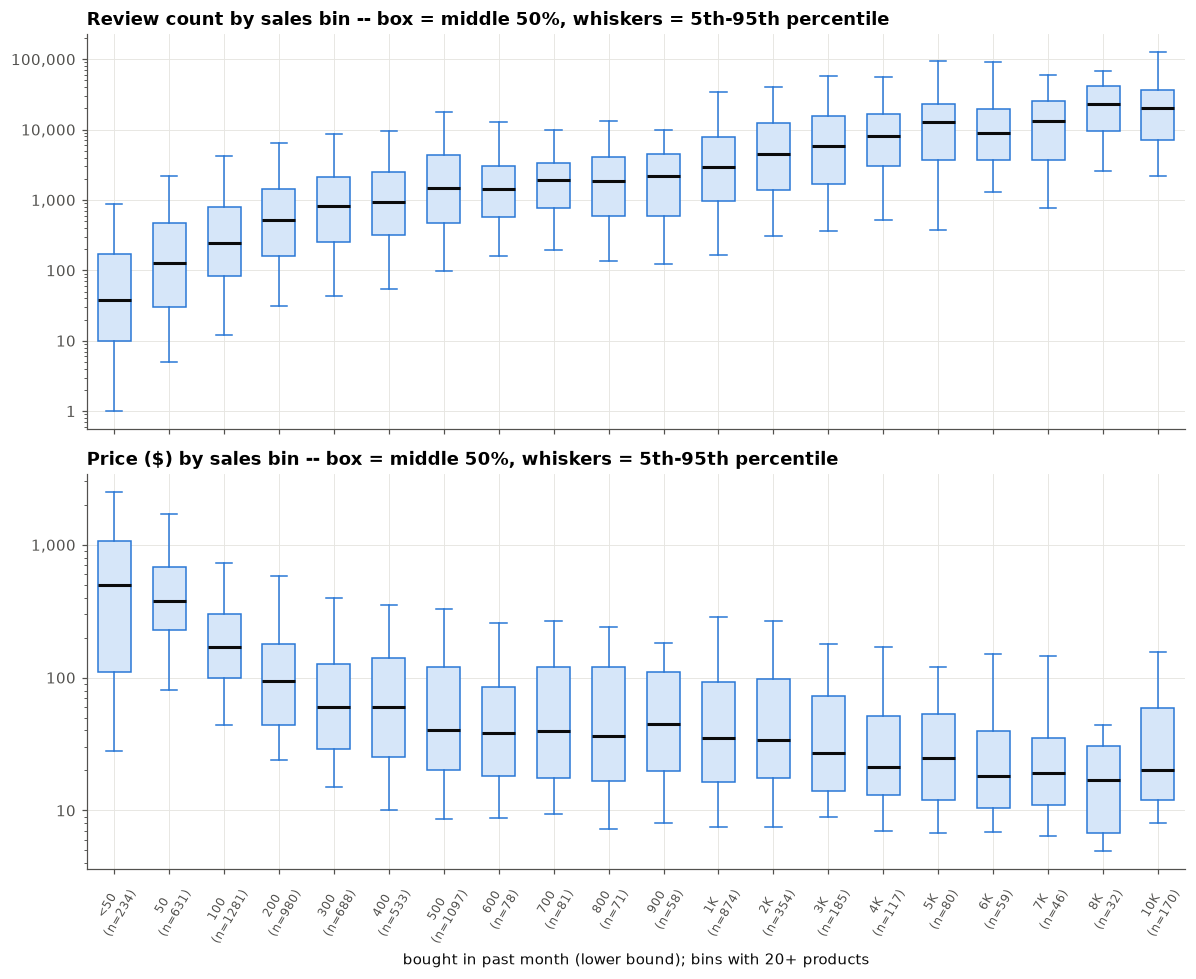

In [9]:
keep = x['bought_in_last_month'].map(x['bought_in_last_month'].value_counts()) >= 20  # drop sparse top bins
vals = sorted(x.loc[keep, 'bought_in_last_month'].unique())
labels = ['<50' if v == 0 else f'{int(v):,}' if v < 1000 else f'{int(v/1000)}K' for v in vals]
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
for ax, col, title in [(axes[0], 'number_of_reviews', 'Review count'), (axes[1], 'current_price', 'Price ($)')]:
    groups = [x.loc[x.bought_in_last_month == v, col].dropna() for v in vals]
    groups = [g[g > 0] for g in groups]  # log scale
    ax.boxplot(groups, whis=(5, 95), showfliers=False, widths=0.6, patch_artist=True,
               boxprops=dict(facecolor='#d6e6f9', edgecolor=BLUE), medianprops=dict(color=INK, lw=2),
               whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE))
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax.yaxis.set_minor_formatter(plt.matplotlib.ticker.NullFormatter())
    ax.set_title(f'{title} by sales bin -- box = middle 50%, whiskers = 5th-95th percentile')
axes[1].set_xticks(range(1, len(vals) + 1), [f'{l}\n(n={int((x.bought_in_last_month == v).sum())})' for l, v in zip(labels, vals)],
                   rotation=60, fontsize=8)
axes[1].set_xlabel('bought in past month (lower bound); bins with 20+ products')
fig.tight_layout();

Strong trend, wide scatter: correlations ~0.6, not ~0.9.

## Is there a mid-price sweet spot?

In [10]:
x = p.dropna(subset=['bought_in_last_month'])
x = x[x.category != 'Other']  # 13 products
rows = []
for cat, g in x.groupby('category'):
    gp = g.dropna(subset=['current_price'])
    rows.append({'category': cat, 'n': len(g),
                 'reviews vs sales': g.number_of_reviews.corr(g.bought_in_last_month, method='spearman'),
                 'price vs sales': gp.current_price.corr(gp.bought_in_last_month, method='spearman')})
pd.DataFrame(rows).set_index('category').sort_values('reviews vs sales').round(2)

,n,reviews vs sales,price vs sales
category,,,
Bags & Cases,122,0.35,-0.46
Gaming,118,0.40,-0.49
Car Electronics,146,0.47,-0.56
Monitors & Displays,328,0.51,-0.48
Phone & Tablet Accessories,414,0.53,-0.46
Smart Home & Wearables,224,0.53,-0.33
Cables & Charging,375,0.54,-0.59
Keyboards & Mice,299,0.55,-0.43
Audio,1195,0.55,-0.39


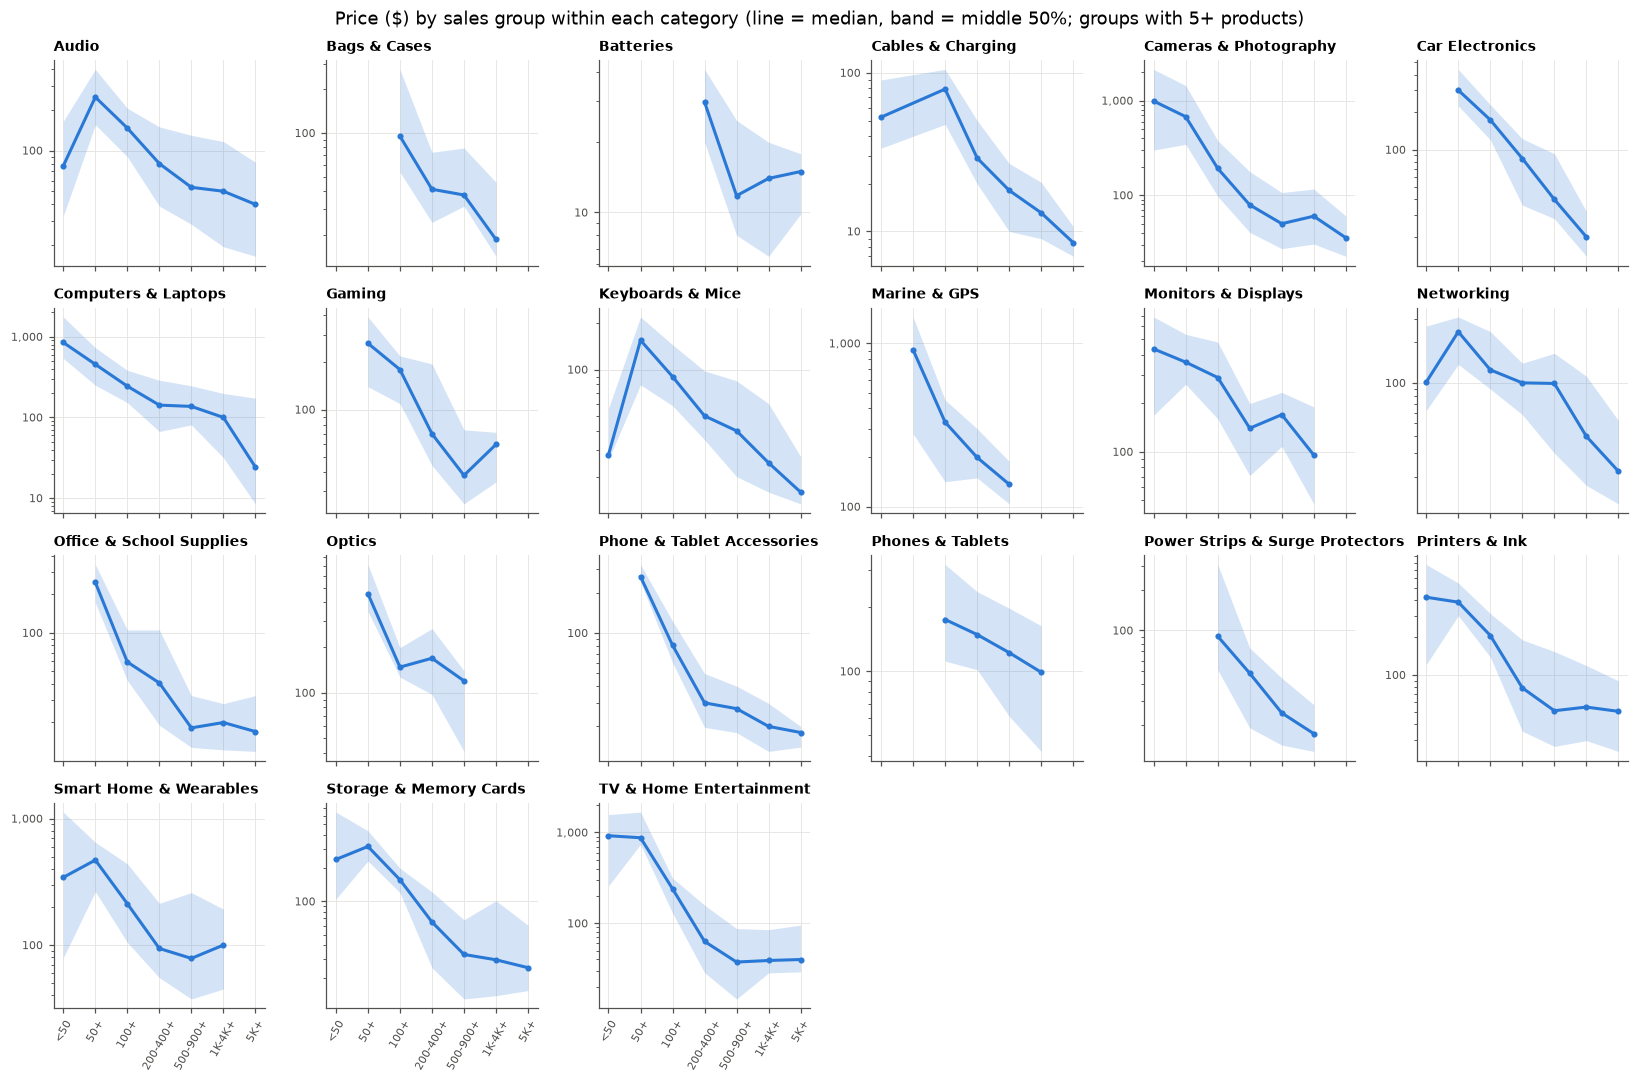

In [11]:
groups = pd.cut(x.bought_in_last_month, [-1, 0, 50, 100, 400, 900, 4000, np.inf],
                labels=['<50', '50+', '100+', '200-400+', '500-900+', '1K-4K+', '5K+'])
cats = sorted(x.category.unique())
for col, ylabel in [('current_price', 'price ($)')]:
    fig, axes = plt.subplots(4, 6, figsize=(15, 10), sharex=True)
    for ax, cat in zip(axes.flat, cats):
        g = x[x.category == cat].assign(grp=groups).dropna(subset=[col])
        q = g.groupby('grp', observed=False)[col].quantile([0.25, 0.5, 0.75]).unstack()
        q = q[g.groupby('grp', observed=False).size() >= 5]  # skip groups with <5 products
        pos = [list(groups.cat.categories).index(i) for i in q.index]
        ax.fill_between(pos, q[0.25], q[0.75], color=BLUE, alpha=0.2, lw=0)
        ax.plot(pos, q[0.5], color=BLUE, lw=2, marker='o', ms=3)
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
        ax.yaxis.set_minor_formatter(plt.matplotlib.ticker.NullFormatter())
        ax.set_title(cat, fontsize=9)
        ax.tick_params(labelsize=7)
    for ax in axes.flat[len(cats):]:
        ax.set_visible(False)
    for ax in axes[-1]:
        ax.set_xticks(range(7), groups.cat.categories, rotation=60)
    fig.suptitle(f'{ylabel.capitalize()} by sales group within each category (line = median, band = middle 50%; groups with 5+ products)')
    fig.tight_layout()

No: in nearly every category cheaper products sell more.

## Where do Amazon's Choice products sit?

Within-category fifths; error bars ±1 SE.

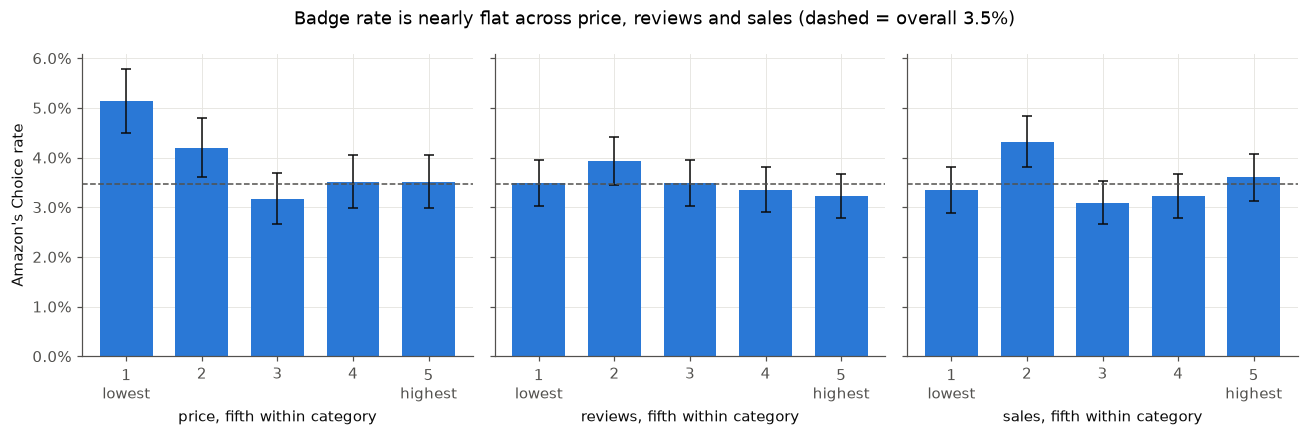

In [12]:
q = p.assign(badge=p['badge_hits'] > 0)  # badged on any scrape
panels = [('current_price', 'price'), ('number_of_reviews', 'reviews'), ('bought_in_last_month', 'sales')]
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, (col, name) in zip(axes, panels):
    fifth = pd.qcut(q.groupby('category')[col].rank(pct=True, method='first'), 5, labels=['1\nlowest', '2', '3', '4', '5\nhighest'])
    r = q.groupby(fifth, observed=True).badge.agg(['mean', 'size'])
    se = np.sqrt(r['mean'] * (1 - r['mean']) / r['size'])
    ax.bar(range(5), r['mean'], color=BLUE, width=0.7)
    ax.errorbar(range(5), r['mean'], yerr=se, fmt='none', ecolor=INK, capsize=3, lw=1)
    ax.axhline(q.badge.mean(), color=MUTED, ls='--', lw=1)
    ax.set_xticks(range(5), r.index)
    ax.set_xlabel(f'{name}, fifth within category')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
axes[0].set_ylabel("Amazon's Choice rate")
fig.suptitle("Badge rate is nearly flat across price, reviews and sales (dashed = overall 3.5%)")
fig.tight_layout()

In [13]:
pd.concat({
    'rating': q.groupby(pd.cut(q.rating, [0, 4, 4.3, 4.5, 4.7, 5]), observed=True).badge.agg(['mean', 'size']),
    'sponsored': q.groupby('is_sponsored').badge.agg(['mean', 'size']),
    'in stock': q.groupby('in_stock').badge.agg(['mean', 'size']),
}).rename(columns={'mean': 'badge rate', 'size': 'products'}).round(3)

badge rate  products
rating    (0.0, 4.0]       0.003       732
          (4.0, 4.3]       0.038      1657
          (4.3, 4.5]       0.032      2084
          (4.5, 4.7]       0.042      2580
          (4.7, 5.0]       0.043       842
sponsored False            0.030      7621
          True             0.148       325
in stock  False            0.023      2565
          True             0.041      5381

Badge rate is flat (3-5%) across price, reviews and sales, but tracks rating, sponsorship (15% vs 3%) and stock → badge model features.

## How often was each product scraped?

scraped <=  1 times: 87.5% of products
scraped <=  2 times: 94.5% of products
scraped <=  5 times: 95.5% of products
scraped <= 20 times: 96.4% of products
top 1% of products = 37% of all rows


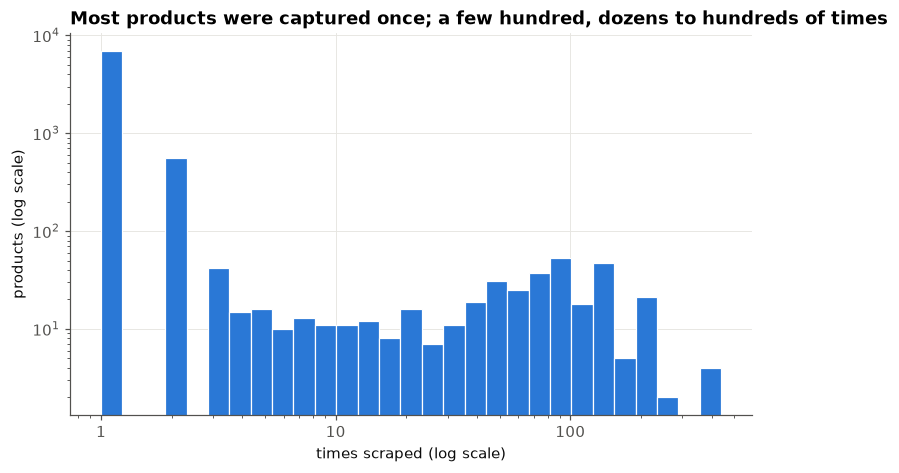

In [14]:
obs = pd.read_csv('../data/amazon_sales_data_cleaned.csv', parse_dates=['collected_at'])
g = obs.groupby('Title').agg(scrapes=('Title', 'size'), sponsored=('is_sponsored', 'mean'),
                             badge=('is_amazons_choice', 'mean'),
                             span_hours=('collected_at', lambda s: (s.max() - s.min()).total_seconds() / 3600))
g = g.join(p.set_index('Title')[['category', 'bought_in_last_month', 'number_of_reviews', 'current_price']])
for k in [1, 2, 5, 20]:
    print(f'scraped <= {k:>2} times: {(g.scrapes <= k).mean():.1%} of products')
top = g.scrapes.sort_values(ascending=False)
print(f'top 1% of products = {top.head(len(g) // 100).sum() / len(obs):.0%} of all rows')

fig, ax = plt.subplots()
ax.hist(g.scrapes, bins=np.logspace(0, np.log10(g.scrapes.max() + 1), 30), color=BLUE, edgecolor='white', linewidth=0.8)
ax.set_xscale('log'); ax.set_yscale('log')
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_xlabel('times scraped (log scale)'); ax.set_ylabel('products (log scale)')
ax.set_title('Most products were captured once; a few hundred, dozens to hundreds of times');

In [15]:
g['times scraped'] = pd.cut(g.scrapes, [0, 1, 2, 5, 20, np.inf], labels=['1', '2', '3-5', '6-20', '21+'])
g.groupby('times scraped', observed=True).agg(
    products=('scrapes', 'size'), share_sponsored=('sponsored', 'mean'), badge_rate=('badge', 'mean'),
    median_hours_first_to_last=('span_hours', 'median'), median_sales=('bought_in_last_month', 'median'),
    median_reviews=('number_of_reviews', 'median'), median_price=('current_price', 'median')).round(2)

,products,share_sponsored,badge_rate,median_hours_first_to_last,median_sales,median_reviews,median_price
times scraped,,,,,,,
1,6953,0.02,0.02,0.00,400.0,992.0,77.19
2,559,0.10,0.02,0.10,100.0,394.0,70.11
3-5,73,0.59,0.04,0.65,100.0,318.0,69.95
6-20,71,0.70,0.05,33.03,200.0,617.0,59.99
21+,290,0.16,0.02,1.02,100.0,293.0,99.99


Heavy repeats are scraper bursts (within an hour, mostly unsponsored, lower sales) → scrape count is not a popularity feature.